In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
casos = pd.read_csv("dataset/201401-202526.csv")
casos.tail()

,SE,data_iniSE,casos
595,202522,2025-05-25,132
596,202523,2025-06-01,90
597,202524,2025-06-08,84
598,202525,2025-06-15,86
599,202526,2025-06-22,71


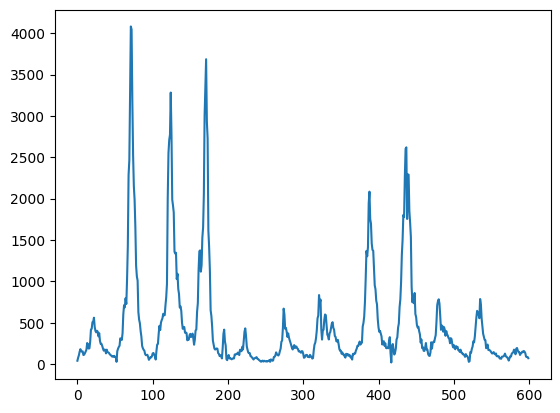

In [3]:
plt.plot(casos['casos'])

In [4]:
real_2025 = casos[ casos['SE'].astype(str).str.startswith('2025') ]
real_2025.head()

,SE,data_iniSE,casos
574,202501,2024-12-29,70
575,202502,2025-01-05,94
576,202503,2025-01-12,90
577,202504,2025-01-19,126
578,202505,2025-01-26,135


In [5]:
previsao = pd.read_csv("dataset/predicao-2025-escala.csv")
previsao.head()

,Point.Forecast,Lo.80,Hi.80,Lo.95,Hi.95
0,42.828145,29.123081,62.982690,23.745015,77.247794
1,36.472855,21.139776,62.927306,15.838327,83.990508
2,143.015040,73.329236,278.924243,51.487889,397.244906
3,127.851512,59.118307,276.496573,39.299971,415.929293
4,151.519071,63.965225,358.914221,40.521288,566.567112


In [6]:
semanas = list()
for semana in range(1, 53):
  if semana < 10:
    semanas.append(f'20250{semana}')
  else:
    semanas.append(f'2025{semana}')

In [12]:
previsao['SE'] = semanas

In [ ]:
real_2025['SE'] = real_2025['SE'].astype(str)
casos['SE'] = casos['SE'].astype(str)

C:\Users\olive\AppData\Local\Temp\ipykernel_8896\1010925257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_2025['SE'] = real_2025['SE'].astype(int)


In [ ]:
merged = pd.merge(previsao, casos[['SE', 'casos']], on='SE', how='left')
previsao.head()

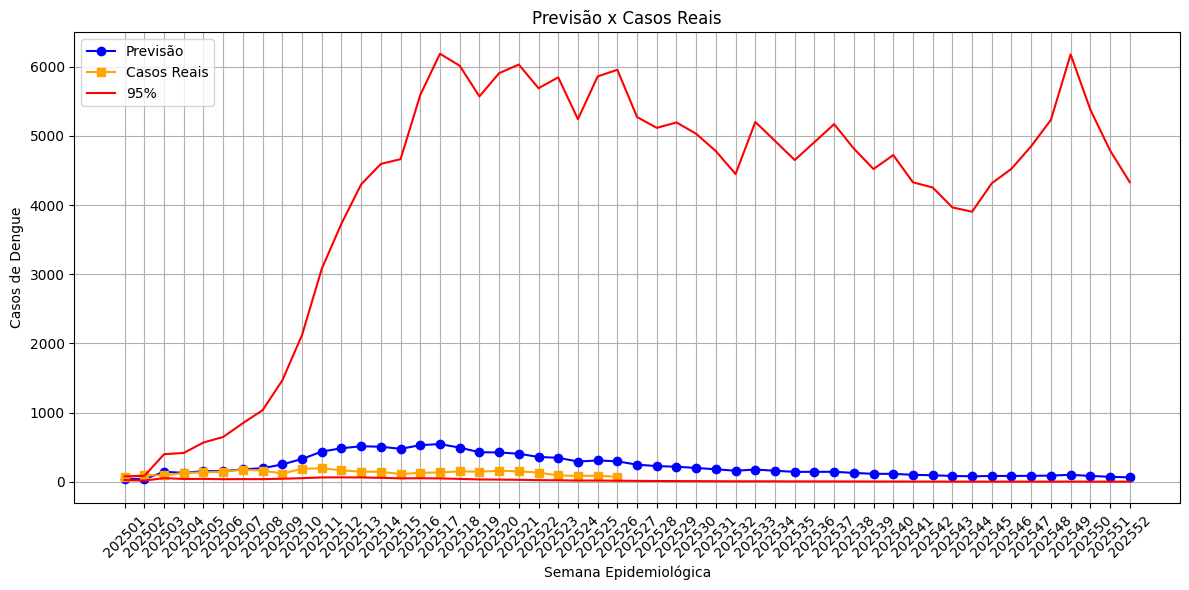

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(merged['SE'], merged['Point.Forecast'], label='Previsão', marker='o', color='blue')
plt.plot(merged['SE'], merged['casos'], label='Casos Reais', marker='s', color="orange")
plt.plot(merged['SE'], merged['Hi.95'], label='95%', color="red")
plt.plot(merged['SE'], merged['Lo.95'], color="red")

plt.xlabel('Semana Epidemiológica')
plt.ylabel('Casos de Dengue')
plt.title('Previsão x Casos Reais')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()